In [1]:
# -*- coding: utf-8 -*-

"""
usage example:
python MedSAM_Inference.py -i assets/img_demo.png -o ./ --box "[95,255,190,350]"

"""

# %% load environment
import numpy as np
import matplotlib.pyplot as plt
import os

join = os.path.join
import torch
from segment_anything import sam_model_registry
from skimage import io, transform
import torch.nn.functional as F
import argparse


In [5]:
# visualization functions
# source: https://github.com/facebookresearch/segment-anything/blob/main/notebooks/predictor_example.ipynb
# change color to avoid red and green
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([251 / 255, 252 / 255, 30 / 255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(
        plt.Rectangle((x0, y0), w, h, edgecolor="blue", facecolor=(0, 0, 0, 0), lw=2)
    )


@torch.no_grad()
def medsam_inference(medsam_model, img_embed, box_1024, H, W):
    box_torch = torch.as_tensor(box_1024, dtype=torch.float, device=img_embed.device)
    if len(box_torch.shape) == 2:
        box_torch = box_torch[:, None, :]  # (B, 1, 4)

    sparse_embeddings, dense_embeddings = medsam_model.prompt_encoder(
        points=None,
        boxes=box_torch,
        masks=None,
    )
    low_res_logits, _ = medsam_model.mask_decoder(
        image_embeddings=img_embed,  # (B, 256, 64, 64)
        image_pe=medsam_model.prompt_encoder.get_dense_pe(),  # (1, 256, 64, 64)
        sparse_prompt_embeddings=sparse_embeddings,  # (B, 2, 256)
        dense_prompt_embeddings=dense_embeddings,  # (B, 256, 64, 64)
        multimask_output=False,
    )

    low_res_pred = torch.sigmoid(low_res_logits)  # (1, 1, 256, 256)

    low_res_pred = F.interpolate(
        low_res_pred,
        size=(H, W),
        mode="bilinear",
        align_corners=False,
    )  # (1, 1, gt.shape)
    low_res_pred = low_res_pred.squeeze().cpu().numpy()  # (256, 256)
    medsam_seg = (low_res_pred > 0.5).astype(np.uint8)
    return medsam_seg

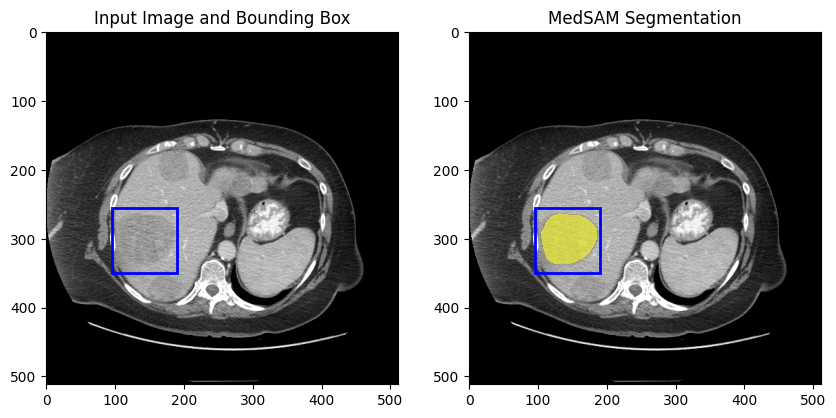

In [7]:
# %% configuration (replace argparse)
data_path = "/home/jovyan/thesis_project/MedSAM/assets/img_demo.png"
seg_path = "/home/jovyan/thesis_project/MedSAM/assets/"
box = [95, 255, 190, 350]  # [x_min, y_min, x_max, y_max]
device = "cuda:0"
checkpoint = "/home/jovyan/thesis_project/MedSAM/work_dir/MedSAM/medsam_vit_b.pth"

# %% load model
medsam_model = sam_model_registry["vit_b"](checkpoint=checkpoint)
medsam_model = medsam_model.to(device)
medsam_model.eval()

# %% load image
img_np = io.imread(data_path)
if len(img_np.shape) == 2:
    img_3c = np.repeat(img_np[:, :, None], 3, axis=-1)
else:
    img_3c = img_np

H, W, _ = img_3c.shape

# %% image preprocessing
img_1024 = transform.resize(
    img_3c, (1024, 1024),
    order=3,
    preserve_range=True,
    anti_aliasing=True
).astype(np.uint8)

img_1024 = (img_1024 - img_1024.min()) / np.clip(
    img_1024.max() - img_1024.min(),
    a_min=1e-8,
    a_max=None
)

img_1024_tensor = (
    torch.tensor(img_1024)
    .float()
    .permute(2, 0, 1)
    .unsqueeze(0)
    .to(device)
)

# %% bounding box
box_np = np.array([box])
box_1024 = box_np / np.array([W, H, W, H]) * 1024

# %% inference
with torch.no_grad():
    image_embedding = medsam_model.image_encoder(img_1024_tensor)

medsam_seg = medsam_inference(
    medsam_model,
    image_embedding,
    box_1024,
    H,
    W
)

# %% save result
io.imsave(
    join(seg_path, "seg_" + os.path.basename(data_path)),
    medsam_seg,
    check_contrast=False,
)

# %% visualize results
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img_3c)
show_box(box_np[0], ax[0])
ax[0].set_title("Input Image and Bounding Box")

ax[1].imshow(img_3c)
show_mask(medsam_seg, ax[1])
show_box(box_np[0], ax[1])
ax[1].set_title("MedSAM Segmentation")

plt.show()